In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import lissa as li

import statsmodels.api as sm

from sklearn.preprocessing import power_transform

import pickle

In [2]:
PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

PCAHeaders = [str(i) for i in range(0,8)]

pumpList = PCAData["Well Run"].unique()


/tmp/ipykernel_103048/452915461.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [3]:
PCAData[["Transformed Radius","VibNormX","VibNormY"]] = 0.0

for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"]==pump]#.copy()
    PCAData.loc[pumpData.index,"Transformed Radius"] = li.BoxCoxProccess(pumpData,"Radius")
    PCAData.loc[pumpData.index,"VibNormX"] = li.BoxCoxProccess(pumpData,"ESP Vibration X")
    PCAData.loc[pumpData.index,"VibNormY"] = li.BoxCoxProccess(pumpData,"ESP Vibration Y")

In [4]:
mainSeed = 19971215
np.random.seed()#mainSeed)

proportion = 0.75

X_train,trainLength, X_test, testLength = li.Splitter(pumpList,proportion,PCAData)

totalLength = np.concatenate([trainLength,testLength])

modelData = pd.concat([X_train,X_test])

/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exportData = pd.concat([exportData,modelData],axis=0)
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exportData = pd.concat([exportData,modelData],axis=0)


In [152]:
n = [4, 4, 4]

In [149]:
#modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],covar_type="diag")
# pickle.dump(modelSq,open("MLmodels/modelSq.sav","wb"))

modelSq = pickle.load(open("MLmodels/modelSq.sav","rb"))

li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
print(modelSq.get_stationary_distribution())
PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))



AIC: 13.023996530503682BIC: 13.024587643330898
[0.26746452 0.2532531  0.270231   0.20905137]


In [150]:
#modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],covar_type="full")
# pickle.dump(modelVib,open("MLmodels/modelVib.sav","wb"))

modelVib = pickle.load(open("MLmodels/modelVib.sav","rb"))
li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
print(modelVib.get_stationary_distribution())
PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))



AIC: 14.517041314933461BIC: 14.517243465027956
[0.35530692 0.112038   0.22280868 0.3098464 ]


In [136]:
#modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],covar_type="full")
#pickle.dump(modelTot,open("MLmodels/modelTot.sav","wb"))

modelTot = pickle.load(open("MLmodels/modelTot.sav","rb"))
li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
print(modelTot.get_stationary_distribution())
PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))



AIC: 15.227579475473963BIC: 15.227724221198226
[0.12927394 0.22805308 0.23853744 0.40413555]


In [144]:
numberOfDays = 7

stats = pd.DataFrame(columns=["State Vib", "State Gaussian","State Tot"])

for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"]==pump]
    if pumpData.loc[pumpData["Failure"]==1].empty != True:
        failure = pumpData.loc[pumpData["Failure"]==1].index[0]
        indexRef = pumpData.index[0]
        selectedData = pumpData.iloc[failure-indexRef-numberOfDays*24:]

        stats = pd.concat([stats, 
                       selectedData.loc[selectedData["Well_down"]==0][["State Vib", "State Gaussian","State Tot"]]])

    

array([[<Axes: title={'center': 'State Vib'}>,
        <Axes: title={'center': 'State Gaussian'}>],
       [<Axes: title={'center': 'State Tot'}>, <Axes: >]], dtype=object)

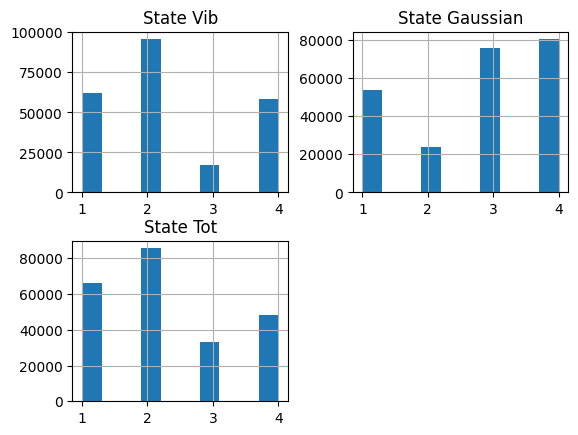

In [145]:
stats.reset_index(inplace=True,drop=True)
stats = stats.infer_objects()
stats.drop(labels=0,inplace=True)
stats.hist()


In [146]:
for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
    fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
    fig.savefig("../imagensHMM/"+pump)
    plt.close()

In [47]:
modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],algorithm="map")
li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
print(modelSq.get_stationary_distribution())
PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))
pickle.dump(modelVib,open("modelSq_map.sav","wb"))

13.67469281719257
[0.14367959 0.3782174  0.07416622 0.4039368 ]


In [48]:
modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],algorithm="map")
li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
print(modelVib.get_stationary_distribution())
PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))
pickle.dump(modelVib,open("modelVib_map.sav","wb"))

14.527220141671705
[0.12034472 0.12745028 0.33351707 0.15200837 0.26667956]


In [49]:
modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],algorithm="map")
li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
print(modelTot.get_stationary_distribution())
PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))
pickle.dump(modelVib,open("modelTot.sav","wb"))

15.232080639158164
[0.24647091 0.2332688  0.40107046 0.11918983]


In [15]:
for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
    fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
    fig.savefig("../imagensHMM_map/"+pump)
    plt.close()

In [147]:
# pump = pumpList[0]

# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)

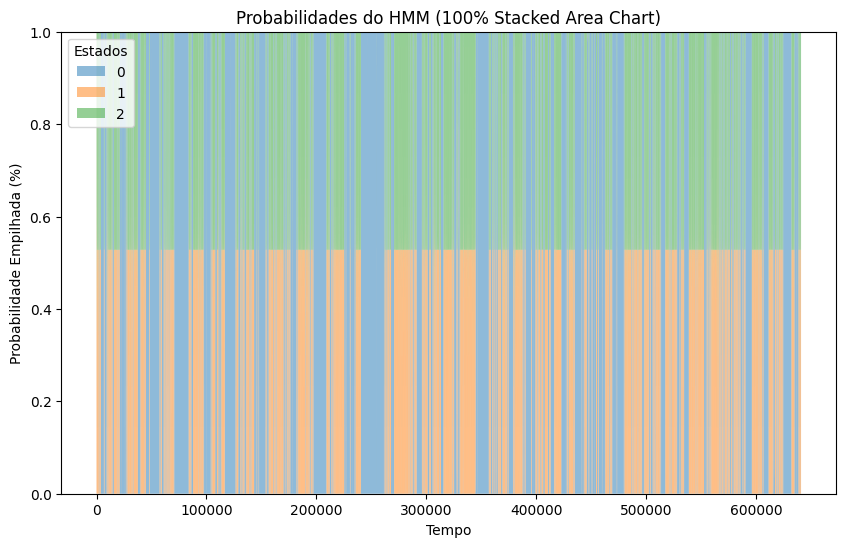

In [14]:
df = pd.DataFrame(modelSq.predict_proba(X_train["Transformed Radius"].to_numpy().reshape(-1,1), trainLength))

# Índices de tempo
time = np.arange(len(df))

# Criar figura
fig, ax = plt.subplots(figsize=(10, 6))

# Cores para os estados
colors = ['#1f77b4', '#ff7f0e', '#2ca02c','#4cff2c','#fcff2c']

# Gráfico de área empilhada com transparência (alpha)
ax.stackplot(time, df.T, labels=df.columns, colors=colors, alpha=0.5)

# Configurações do gráfico
ax.set_xlabel("Tempo")
ax.set_ylabel("Probabilidade Empilhada (%)")
ax.set_title("Probabilidades do HMM (100% Stacked Area Chart)")
ax.legend(title="Estados", loc='upper left')
plt.ylim(0, 1)  # Mantém o eixo Y de 0 a 1 (100%)

# Exibir o gráfico
plt.show()


In [17]:
# for pump in pumpList:
   
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     fig, axs = li.HMMPicture(pumpData,pump,PCAHeaders,cmap1,n_1)

#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [18]:
# import dynamax.hidden_markov_model as hmm


# model = hmm.LinearAutoregressiveHMM(num_states=4,emission_dim=5)
# model.fit_em()


#  pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     pumpData["time"] = pd.to_datetime(pumpData["time"])
#     pumpData.set_index("time",inplace=True)

#     pumpData = pumpData.asfreq('h',fill_value=0)

#     pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])

#     fig, ax = plt.subplots(4,1, figsize=(50,15))

#     pumpData[PCAHeaders].plot(ax=ax[0])


#     # Preenchendo as áreas de acordo com os estados
#     for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax[0].fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"Estado {state}")
        
#     ax[0].legend(loc='upper left',bbox_to_anchor=(1, 1))


#     # for shut in pumpData["Shutdown"].loc[pumpData["Shutdown"] == True].index:
#     #       ax[0].axvline(x=shut, color='black', linestyle='-', linewidth=0.5)





#     norm = mcolors.Normalize(vmin=-6, vmax=6)

#     its = ax[3].pcolor(pumpData[PCAHeaders].T,cmap='hsv', norm=norm)
#     ax[3].grid(axis="y",linewidth=1,color="black")
#     ax[3].tick_params(axis='both', which='both', length=0)  # Remove ticks
#     ax[3].set_xticklabels([])  # Remove labels no eixo x


#     ax[3].set_title(str(pumpData["Pump Info"].iloc[0])+" "+str(pumpData["Failure Info"].iloc[0]))




#     if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#             failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#             ax[3].axvline(x=failureX, color='red', linestyle='--', linewidth=1)


#     fig.colorbar(its,ax=ax[3],orientation='horizontal',shrink=0.5)


#     fig.suptitle("HMM e Imshow: " + pump);
#     plt.tight_layout()
#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [19]:
# pump = pumpList[0]
# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# plt.rcParams['font.size'] = 15.0
# pumpData["time"] = pd.to_datetime(pumpData["time"])
# pumpData.set_index("time",inplace=True)

# pumpData = pumpData.asfreq('h',fill_value=0)

# pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])


# fig, ax = plt.subplots(1,1, figsize=(20,10))

# pumpData[PCAHeaders].plot(ax=ax)


# # Preenchendo as áreas de a
# # cordo com os estados
# for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax.fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"State {state}")

#         ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)



# if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#         #failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#         ax.axvline(x=pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)


# fig.suptitle("HMM: " + pump,fontsize=20);
# fig.savefig("imagens/relatorio/hmm")